Install Neo4j
--
1. You can install Neo4j here: https://neo4j.com/deployment-center/#releases
Make sure you have the right Java version to run Neo4j.

2. Unpack the archive to a chosen location in the file system. It would create a Neo4J directory, it will be referred to as Neo4J directory later on.
   
3.
Go to the Neo4J directory and run the database locally by issuing the following command:

bin/neo4j con. l
e
Open http://localhost:7474/ in a breowsr! .

The default username: neo4j, pass neo4j

! o4j. Warning: before doing anything the web interface would ask you to change the defau pas
sword.

Cypher language
--
1. Let's start with creating a simple graph
https://neo4j.com/docs/cypher-manual/current/clauses/create/
Create two nodes representing two classmates. To each node add a lable Person and add a property 'name' with the name of the classmate.

STRUCTURE:
CREATE (a:Label1:Label2 {name:'property1', name2: 'property2'})

2. Create a connection between your two nodes representing the relationship between classmates
https://neo4j.com/docs/cypher-manual/current/clauses/match/

! The arrow signified the direction of the connection. In neo4j there's no biderectional connections.

STRUCTURE:
MATCH (a {name: 'a_property1'}), (b {name: 'b_property1'}) CREATE (a)-[:lable1:lable2 {name: 'attribute1', name2: 'attribute2'}]-> (b);

3. Now create a club (node) that students can join, lable it as a club and add a property that describes genere of the club and one for the name of the club.

4. Create a connection between two classmates and the club signifying their belonging to the club, add the date they joined the club (use date() to signify the date format of the data)

5. Expand your graph by adding more classmates (at least 5) and clubs (at least 2). Make connections between classmates signifying their relationships and between classmates and clubs signifying them being members of the club (classmates can be members of more than one club, not all students have to belong to a club and have a defined relationship)


Example solution

1.
CREATE (N1:Person {name:"Marta"});
CREATE (N2:Person {name:"Adam"});
CREATE (N3:Person {name: "Ania";

2.
MATCH (a {name: 'Ania'}), (b {name: 'Marta'}) CREATE (a)-[:RELATIONSHIP {type: 'friends'}]-> (b);
3.
create (C1:Club {field: "math", name: "mathlets"})

4.
MATCH (a {name: 'Ania'}), (b:Club) CREATE (a)-[:MEMBER]-> (b);
MERGE (a:Person {name:"Ania"})-[x:MEMBER]->(b:Club {name:"mathlets"}) set x.startDate = date('2012-02-15') return x.startDate;
})

! To display all the nodes in the database and observe the created graph you can use:
MATCH (n) RETURN n

! If you want to delete all existing connections and nodes you can use:
match (n) detach delete n
! Your graph can have unconnected nodes but it CANNOT have an "empty" connection, which means that you cannot delete a connected node without deleting the connections as well, that's while deleting we also have to use DETACH.

6. Searching the graph
   
   6.1. Check if there are any nodes with no connections.
   
   6.2. Count all the clubs in your graph.
   
   6.3. Display all the members of one of the clubs.
   
   6.4. Find all the members of one of the clubs who joined before 2023.


EXAMPLE SOLUTION

6.1
MATCH (d) WHERE NOT (d)-[]-() RETURN d;

6.2
MATCH (f:Club) RETURN COUNT(f);

6.3
MATCH (a:Person)-[x]->(b:Club {name:'mathlets'})  return a;

6.4
MATCH (a:Person)-[x]->(b:Club) where x.startDate<date("2023-01-01") return a,x,b
;


Neo4j in a Python notebook.
-----
Let's explore different libraries for Neo4j in Python

In this notebook we will explore two libraries for neo4j integration with Python:

Py2neo
https://pypi.org/project/py2neo/

Neo4j
https://neo4j.com/developer/python/

Other available libraries for neo4j and Python integration:

GraphDataScience
https://pypi.org/project/graphdatascience/

Igraph
https://igraph.org/

ipython-cypher
https://pypi.org/project/ipython-cypher/

py2neo library
--

In [ ]:
#!pip install py2neo

In [ ]:
import py2neo
from py2neo import Graph,Node,Relationship
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
username = 'neo4j'
password = ''
graph = Graph('http://localhost:7474/', auth=(username, password), name="neo4j")

In [ ]:
q1 = "MATCH (f:Club) RETURN COUNT(f)"
r1 = graph.evaluate(q1)
print(f"Number of clubs: {r1}")

Number of clubs: 5


In [ ]:
q2 = "MATCH (f:Person) RETURN COUNT(f)"
r2 = graph.evaluate(q2)


Text(0, 0.5, 'Number of Nodes')

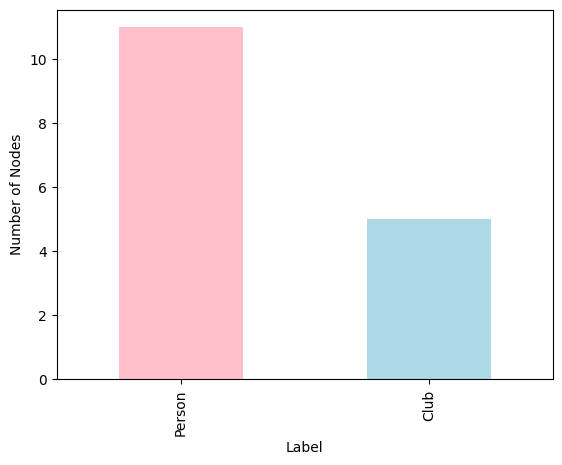

In [ ]:
plot1 = pd.Series({"Person":r2, "Club":r1})
plot1.plot(kind='bar', color=['pink', 'lightblue'])
plt.xlabel('Label')
plt.ylabel('Number of Nodes')

Write a querry that will show all relation types in your graph (use DISTINCT).

In [ ]:
relationship_types = "MATCH (n)-[r]-(m) RETURN DISTINCT type(r) as RelationType"

graph.run(relationship_types).to_data_frame()

,RelationType
0,RELATIONSHIP
1,MEMBER


Now try to write a querry to display all classmates in your graph and the clubs they belong to. Present the results as a dataframe as shown in the previous example.

In [ ]:
classmates_clubs="MATCH (p:Person)-[r:MEMBER]->(m:Club) RETURN DISTINCT p.name as PersonName,m.name as MClubName ORDER BY PersonName ASC"

graph.run(classmates_clubs).to_data_frame()

,PersonName,MClubName
0,Adrian,Volleyball
1,Ania,mathlets
2,Julia,Discover


Integration of the notebook with neo4j allows you to add new nodes and relationships your graph as well.

In [ ]:
from py2neo import Node, Relationship

#Create a new node for a classmate
new_person = Node("Person",name="Adrian")
new_person
#Create a new node for a club
new_club=Node("Club",field="sports",name="Volleyball")
new_club
#Now insert both the nodes in the graph
t=graph.begin()
t.create(new_person)
t.create(new_club)
#Create the relationship between the created nodes
t.create(Relationship(new_person, "MEMBER", new_club))
graph.commit(t)

In [ ]:
graph.run(classmates_clubs).to_data_frame()

,PersonName,MClubName
0,Adrian,Volleyball
1,Ania,mathlets
2,Julia,Discover


Python's Neo4j library
--

https://neo4j.com/docs/python-manual/current/

In [ ]:
#!pip install neo4j

In [ ]:
from neo4j import GraphDatabase

In [ ]:
driver = GraphDatabase.driver('bolt::7474/', auth=("neo4j", password))

In [ ]:
query = "MATCH (n) RETURN COUNT(n)"

In [ ]:
with driver.session() as session:
    result = session.run(query)
    print(result.single()["COUNT(n)"])

2006


Working with csv for data visualization

In [ ]:
import time
import pandas as pd

In [ ]:
test_df = pd.read_csv('test.csv')
test_df = train_df.drop_duplicates()
test_df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [ ]:
test_df.shape

(15999, 2)

In [ ]:
class Neo4jConnection:

    def __init__(self, uri, user, pwd):
        self.__uri = uri
        self.__user = user
        self.__pwd = pwd
        self.__driver = None
        try:
            self.__driver = GraphDatabase.driver(self.__uri, auth=(self.__user, self.__pwd))
        except Exception as e:
            print("Failed to create the driver:", e)

    def close(self):
        if self.__driver is not None:
            self.__driver.close()

    def query(self, query, parameters=None, db=None):
        assert self.__driver is not None, "Driver not initialized!"
        session = None
        response = None
        try:
            session = self.__driver.session(database=db) if db is not None else self.__driver.session()
            response = list(session.run(query, parameters))
        except Exception as e:
            print("Query failed:", e)
        finally:
            if session is not None:
                session.close()
        return response

In [ ]:
uri = 'bolt::7474/'

conn = Neo4jConnection(uri=uri, user="neo4j", pwd=password)

In [ ]:
conn.query('LOAD CSV WITH HEADERS FROM "file:///test.csv" AS row WITH row WHERE row.label IS NOT NULL MERGE (t:Emotion {label: row.label})')

[]

In [ ]:
conn.query('LOAD CSV WITH HEADERS FROM "file:///test.csv" AS row WITH row LIMIT 1000 WHERE row.label IS NOT NULL MERGE (t:Tweet {text: row.text, label:row.label})')

[]

In [ ]:
conn.query('MATCH (a:Emotion {label: "0"}), (b:Tweet {label: "0"}) CREATE (b)-[:classification {name: "sadness"}]-> (a);')
conn.query('MATCH (a:Emotion {label: "1"}), (b:Tweet {label: "1"}) CREATE (b)-[:classification {name: "joy"}]-> (a);')
conn.query('MATCH (a:Emotion {label: "2"}), (b:Tweet {label: "2"}) CREATE (b)-[:classification {name: "love"}]-> (a);')
conn.query('MATCH (a:Emotion {label: "3"}), (b:Tweet {label: "3"}) CREATE (b)-[:classification {name: "anger"}]-> (a);')
conn.query('MATCH (a:Emotion {label: "4"}), (b:Tweet {label: "4"}) CREATE (b)-[:classification {name: "fear"}]-> (a);')
conn.query('MATCH (a:Emotion {label: "5"}), (b:Tweet {label: "5"}) CREATE (b)-[:classification {name: "surprise"}]-> (a);')

[]

In [ ]:
conn.query('match (n) return count(n)')

[<Record count(n)=1006>]

Observe the result in your neo4j consol in browser.

Example of using neo4j for graph creation for a Kaggle competition:

https://www.youtube.com/watch?v=PEZaNW4IhBs&list=PL9Hl4pk2FsvVShoT5EysHcrs-hyCsXaWC&index=6
https://www.youtube.com/watch?v=9q3KC5I2CA0&list=PL9Hl4pk2FsvVShoT5EysHcrs-hyCsXaWC&index=5
https://www.youtube.com/watch?v=B1a3b5x1BOU&list=PL9Hl4pk2FsvVShoT5EysHcrs-hyCsXaWC&index=4
https://www.youtube.com/watch?v=9SvTyCoapuo&list=PL9Hl4pk2FsvVShoT5EysHcrs-hyCsXaWC&index=3
https://www.youtube.com/watch?v=N0TKBJJjnbg&list=PL9Hl4pk2FsvVShoT5EysHcrs-hyCsXaWC&index=2